# 04 — False positives: the banks the model flagged that did not fail

A bank in the top 2 percent of a quarter's ranking that does not fail within four
quarters counts against the model in every metric of notebook 02. Whether it *should*
count against the model is the question here. A troubled bank has three ways out of the
sample: it fails, it is bought (often by a healthier bank, sometimes with the supervisor
holding the door), or it recapitalises and survives. Only the first is a positive label.
This notebook takes the walk-forward gradient booster at the 4-quarter horizon, finds the
highest-scored bank-quarters that carry `y = 0`, and follows each bank for eight quarters
in the panel to see what happened to it. Everything is read from `data/parquet/`; the
tables are saved to `reports/false_positives.md`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "config" / "settings.yaml").exists() else Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from bankcanary.config import load_settings
from bankcanary.evaluation.metrics import rank_order
from bankcanary.storage.parquet import read_table, table_path

settings = load_settings()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 60)
plt.rcParams["figure.dpi"] = 100
MODEL, HORIZON, TOP_FRAC, FOLLOW_QUARTERS = "gbdt", 4, 0.02, 8
CRISIS_YEARS = [2009, 2010, 2011, 2012]

wf = read_table("walkforward_scores", settings)
scores = wf[(wf["model"] == MODEL) & (wf["horizon"] == HORIZON)].copy()
panel = pd.read_parquet(
    table_path(settings, "panel"),
    columns=["cert", "repdte", "name", "stalp", "asset", "avail_date", "fail_date", "exit_date", "exit_reason"],
)
print(f"{len(scores):,} scored bank-quarters, {int(scores['y'].sum()):,} positives, test years "
      f"{scores['test_year'].min()}-{scores['test_year'].max()}")

426,019 scored bank-quarters, 2,103 positives, test years 2008-2024


## 1. Who is in the top 2 percent, and who among them did not fail

The flag is the same one the lead-time metric uses: within every report quarter the
banks are ranked by score (ties by `cert`) and the top `ceil(2% × n)` are flagged. A
flagged bank-quarter with `y = 0` is a false positive *for that quarter*. To count banks
rather than quarters, each flagged non-failing bank is kept once per test year, at the
quarter where its score was highest, and followed from that report for eight quarters.

In [2]:
scores["flagged"] = False
for _, idx in scores.groupby("repdte").indices.items():
    sub = scores.iloc[idx]
    order = rank_order(sub["score"].to_numpy(), sub["cert"].to_numpy())
    k = max(1, int(np.ceil(TOP_FRAC * len(sub))))
    scores.iloc[idx[order[:k]], scores.columns.get_loc("flagged")] = True
flagged = scores[scores["flagged"]]
fp_rows = flagged[flagged["y"] == 0]
print(f"flagged bank-quarters: {len(flagged):,}; of which failed within 4q: {int(flagged['y'].sum()):,} "
      f"({flagged['y'].mean():.1%}); did not: {len(fp_rows):,}")
fp = (fp_rows.sort_values(["test_year", "cert", "score"], ascending=[True, True, False])
      .groupby(["test_year", "cert"], as_index=False).head(1)
      .merge(panel, on=["cert", "repdte"], how="left"))
fp["follow_end"] = fp["avail_date"] + pd.DateOffset(months=3 * FOLLOW_QUARTERS)
fp["window_end"] = fp["avail_date"] + pd.DateOffset(months=3 * HORIZON)
print(f"distinct flagged non-failing banks per test year: {len(fp):,} rows, {fp['cert'].nunique():,} banks")

flagged bank-quarters: 8,553; of which failed within 4q: 1,157 (13.5%); did not: 7,396
distinct flagged non-failing banks per test year: 3,713 rows, 1,683 banks


## 2. What happened to them within eight quarters

Each bank is classified by the first thing the panel records after the flagged report:

- **failed later (5-8q)**: `fail_date` after the 4-quarter label window but within eight
  quarters of `avail_date`, so the flag was early rather than wrong;
- **failed after 8q**: a later failure still;
- **acquired**: `exit_reason` of `merger`, `absorption`, `affiliated_merger` or
  `consolidation` with `exit_date` inside the eight quarters;
- **closed voluntarily** / **other exit**: the remaining exit codes inside the window;
- **still open after 8q**: no failure and no exit in the window.

In [3]:
ACQUIRED = {"merger", "absorption", "affiliated_merger", "consolidation"}
OUTCOMES = ["failed later (5-8q)", "failed after 8q", "acquired", "closed voluntarily", "other exit", "still open after 8q"]

def classify(r):
    if pd.notna(r["fail_date"]) and r["fail_date"] > r["window_end"]:
        return "failed later (5-8q)" if r["fail_date"] <= r["follow_end"] else "failed after 8q"
    if pd.notna(r["exit_date"]) and r["exit_date"] > r["repdte"] and r["exit_date"] <= r["follow_end"]:
        if r["exit_reason"] in ACQUIRED:
            return "acquired"
        if r["exit_reason"] == "voluntary_closing":
            return "closed voluntarily"
        return "other exit"
    return "still open after 8q"

fp["outcome"] = pd.Categorical(fp.apply(classify, axis=1), categories=OUTCOMES)
fp["merged_within_2y"] = (fp["outcome"] == "acquired") & (fp["exit_reason"] == "merger")

def outcome_table(frame):
    counts = frame.groupby("test_year", observed=False)["outcome"].value_counts().unstack(fill_value=0)[OUTCOMES]
    counts.insert(0, "flagged non-failures", counts.sum(axis=1))
    return counts

by_year = outcome_table(fp)
crisis = fp[fp["test_year"].isin(CRISIS_YEARS)]
pooled = by_year.loc[CRISIS_YEARS].sum().to_frame("pooled 2009-2012").T
all_years = by_year.sum().to_frame("all years 2008-2024").T
table_counts = pd.concat([by_year.loc[CRISIS_YEARS].rename(index=str), pooled, all_years])
table_shares = table_counts[OUTCOMES].div(table_counts["flagged non-failures"], axis=0)
table_counts

outcome,flagged non-failures,failed later (5-8q),failed after 8q,acquired,closed voluntarily,other exit,still open after 8q
2009,252,50,25,23,2,0,152
2010,238,42,28,20,4,0,144
2011,179,36,14,15,3,0,111
2012,206,24,12,29,7,0,134
pooled 2009-2012,875,152,79,87,16,0,541
all years 2008-2024,3713,239,165,393,71,2,2843


In [4]:
share_pct = table_shares.map(lambda v: f"{v:.1%}")
share_pct

outcome,failed later (5-8q),failed after 8q,acquired,closed voluntarily,other exit,still open after 8q
2009,19.8%,9.9%,9.1%,0.8%,0.0%,60.3%
2010,17.6%,11.8%,8.4%,1.7%,0.0%,60.5%
2011,20.1%,7.8%,8.4%,1.7%,0.0%,62.0%
2012,11.7%,5.8%,14.1%,3.4%,0.0%,65.0%
pooled 2009-2012,17.4%,9.0%,9.9%,1.8%,0.0%,61.8%
all years 2008-2024,6.4%,4.4%,10.6%,1.9%,0.1%,76.6%


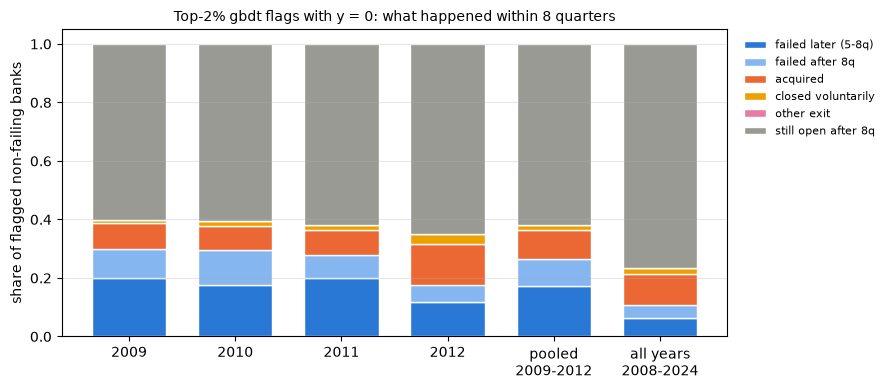

In [5]:
OUTCOME_COLORS = {"failed later (5-8q)": "#2a78d6", "failed after 8q": "#86b6ef", "acquired": "#eb6834",
                  "closed voluntarily": "#eda100", "other exit": "#e87ba4", "still open after 8q": "#9a9a94"}
fig, ax = plt.subplots(figsize=(9, 4))
labels = [str(y) for y in CRISIS_YEARS] + ["pooled 2009-2012", "all years 2008-2024"]
short = [str(y) for y in CRISIS_YEARS] + ["pooled\n2009-2012", "all years\n2008-2024"]
bottom = np.zeros(len(labels))
for o in OUTCOMES:
    vals = table_shares.loc[labels, o].to_numpy()
    ax.bar(short, vals, bottom=bottom, color=OUTCOME_COLORS[o], label=o, width=0.7, edgecolor="white", linewidth=1)
    bottom += vals
ax.set_ylabel("share of flagged non-failing banks")
ax.set_title(f"Top-2% {MODEL} flags with y = 0: what happened within {FOLLOW_QUARTERS} quarters", fontsize=10)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

## 3. How many of the top-2% non-failures left by merger within two years

In [6]:
merger_share = pd.DataFrame({
    "flagged non-failing banks": [len(crisis), len(fp)],
    "exited via merger within 2y": [int(crisis["merged_within_2y"].sum()), int(fp["merged_within_2y"].sum())],
    "acquired (any code) within 2y": [int((crisis["outcome"] == "acquired").sum()), int((fp["outcome"] == "acquired").sum())],
    "failed later (5-8q)": [int((crisis["outcome"] == "failed later (5-8q)").sum()), int((fp["outcome"] == "failed later (5-8q)").sum())],
}, index=["pooled 2009-2012", "all years 2008-2024"])
merger_share["merger share"] = merger_share["exited via merger within 2y"] / merger_share["flagged non-failing banks"]
merger_share["acquired share"] = merger_share["acquired (any code) within 2y"] / merger_share["flagged non-failing banks"]
base = (scores[scores["test_year"].isin(CRISIS_YEARS)].sort_values(["test_year", "cert", "repdte"])
        .groupby(["test_year", "cert"], as_index=False).head(1).merge(panel, on=["cert", "repdte"], how="left"))
base_end = base["avail_date"] + pd.DateOffset(months=3 * FOLLOW_QUARTERS)
base_merged = base["exit_reason"].eq("merger") & (base["exit_date"] > base["repdte"]) & (base["exit_date"] <= base_end)
base_failed = base["fail_date"].notna() & (base["fail_date"] <= base_end)
merger_share.loc["every bank-year 2009-2012 (base rate)"] = [len(base), int(base_merged.sum()), np.nan, np.nan, base_merged.mean(), np.nan]
print(f"base rate over every 2009-2012 bank-year: merger exit within 2y {base_merged.mean():.1%}, failure within 2y {base_failed.mean():.1%}")
merger_share.round(3)

base rate over every 2009-2012 bank-year: merger exit within 2y 5.1%, failure within 2y 2.1%


,flagged non-failing banks,exited via merger within 2y,acquired (any code) within 2y,failed later (5-8q),merger share,acquired share
pooled 2009-2012,875.0,78.0,87.0,152.0,0.089,0.099
all years 2008-2024,3713.0,318.0,393.0,239.0,0.086,0.106
every bank-year 2009-2012 (base rate),31376.0,1613.0,NaN,NaN,0.051,NaN


## 4. Five named examples and what drove their scores

The five highest-scored flagged banks of 2009-2012 that did not fail within four
quarters, with the three features that raised their score most (the `drivers` table
holds the LightGBM log-odds contributions of the walk-forward booster for that
bank-quarter). Assets are in millions of dollars at the flagged report.

In [7]:
ranked = crisis.sort_values("score", ascending=False).groupby("cert", as_index=False).head(1)
picks = {"acquired": 2, "failed later (5-8q)": 1, "still open after 8q": 2}
examples = pd.concat([ranked[ranked["outcome"] == o].head(n) for o, n in picks.items()]).sort_values("score", ascending=False).copy()
history = pd.read_parquet(table_path(settings, "history"), columns=["cert", "effdate", "changecode", "acq_instname"])
acq = history[history["acq_instname"].notna()].groupby(["cert", "effdate"])["acq_instname"].first()
examples["acquirer"] = [acq.get((c, d), "") if pd.notna(d) else "" for c, d in zip(examples["cert"], examples["exit_date"])]
keys = list(zip(examples["cert"], examples["repdte"]))
drivers = pd.read_parquet(table_path(settings, "drivers"),
                          filters=[("model", "==", MODEL), ("cert", "in", sorted(set(examples["cert"])))])
drivers = drivers[[k in set(keys) for k in zip(drivers["cert"], drivers["repdte"])]]
top3 = (drivers[drivers["direction"] == "raises"].sort_values("rank").groupby(["cert", "repdte"])
        .apply(lambda g: "; ".join(f"{f} = {v:.3g} (+{s:.2f})" for f, v, s in zip(g["feature"][:3], g["feature_value"][:3], g["shap_value"][:3])),
               include_groups=False).rename("top drivers"))
examples = examples.merge(top3, left_on=["cert", "repdte"], right_index=True, how="left")
examples["assets $M"] = (examples["asset"] / 1000).round(0).astype(int)
examples["exit"] = [f"{o}" + (f" ({r}, {d:%Y-%m-%d}" + (f", to {a}" if a else "") + ")" if pd.notna(d) and o != "still open after 8q" and not o.startswith("failed") else "")
                    + (f" ({d2:%Y-%m-%d})" if o.startswith("failed") else "")
                    for o, r, d, a, d2 in zip(examples["outcome"], examples["exit_reason"], examples["exit_date"], examples["acquirer"], examples["fail_date"])]
show = examples[["cert", "name", "stalp", "repdte", "score", "assets $M", "exit", "top drivers"]].reset_index(drop=True)
show

,cert,name,stalp,repdte,score,assets $M,exit,top drivers
0,35376,FRIENDS BANK,FL,2010-12-31,1.000000,147,still open after 8q,d4q_tier1_leverage = -3.75 (+9.38); d4q_texas_ratio = 0....
1,58421,FIRST CITIZENS BANK OF GA,GA,2010-06-30,1.000000,112,still open after 8q,d4q_texas_ratio = 0.516 (+10.85); d4q_tier1_leverage = -...
2,35299,SECURITY EXCHANGE BANK,GA,2010-09-30,0.999942,178,failed later (5-8q) (2012-06-15),d4q_tier1_leverage = -2.12 (+10.48); construction_to_cap...
3,29272,BROOKLYN FSB,NY,2010-12-31,0.999088,482,"acquired (merger, 2012-01-07, to Investors Bank)",d4q_tier1_leverage = -7.56 (+8.44); texas_ratio = 0.78 (...
4,58211,SUNRISE BANK OF ATLANTA,GA,2010-06-30,0.999071,53,"acquired (merger, 2010-07-30, to Sunrise Bank)",d4q_tier1_leverage = -6.97 (+7.95); texas_ratio = 0.78 (...


## 5. Interpretation

Of the 875 bank-years that the booster put in the top 2 percent of 2009-2012 without a
failure inside the four-quarter window, about a quarter did fail: 17 percent in quarters
five to eight and another 9 percent later still, against a 2 percent two-year failure
rate for every bank-year of those years. A further 10 percent were acquired within two
years (9 percent through a recorded merger, against a 5 percent base rate), and 2
percent closed voluntarily, which for a bank with a Texas ratio near one usually means
its charter was surrendered after the loans were sold. So close to 40 percent of the
"false positives" of the crisis years are banks that left the industry or failed on a
longer clock, and the acquired group looks like the "rescued" troubled bank the spec
asks about: Brooklyn Federal Savings Bank was flagged at the end of 2010 on a collapsing
leverage ratio and a Texas ratio of 0.78 and was absorbed by Investors Bank a year later;
Sunrise Bank of Atlanta was folded into its sister Sunrise Bank the quarter after its
flag. The model was reading the same balance sheet the acquirer and the supervisor
read; the label says no because the resolution was a sale rather than a receivership.

The remaining 62 percent were still open two years on, and that is the genuine false
alarm rate, with three qualifications. First, the 2010 model saturates: 68 bank-quarters
score above 0.999 and 44 of them failed, so ties at the top of the 2010 ranking are
decided by `cert`, and the two "still open" examples (Friends Bank, First Citizens Bank
of Georgia) sit there on the same drivers as the failures, a one-year drop of two to
four points in Tier 1 leverage and a Texas ratio that rose by half. Second, survival is
not recovery: a bank that raised capital, sold its construction book or shrank its way
back to a passing leverage ratio was troubled when it was flagged, and a supervisor
would have wanted the flag. Third, outside the crisis the picture inverts (77 percent of
all-year flags still open after eight quarters, 11 percent acquired) because there were
few failures to find at all, and a fixed 2 percent head has to be filled with somebody.
The right reading is that the top 2 percent is a watch list rather than a verdict:
roughly one flagged bank in seven fails within the year, one in four within a few
years, one in ten is bought, and the rest are the banks that had the same symptoms and
got better.

## 6. Save the tables

In [8]:
INTERPRETATION_TEXT = 'Of the 875 bank-years that the booster put in the top 2 percent of 2009-2012 without a\nfailure inside the four-quarter window, about a quarter did fail: 17 percent in quarters\nfive to eight and another 9 percent later still, against a 2 percent two-year failure\nrate for every bank-year of those years. A further 10 percent were acquired within two\nyears (9 percent through a recorded merger, against a 5 percent base rate), and 2\npercent closed voluntarily, which for a bank with a Texas ratio near one usually means\nits charter was surrendered after the loans were sold. So close to 40 percent of the\n"false positives" of the crisis years are banks that left the industry or failed on a\nlonger clock, and the acquired group looks like the "rescued" troubled bank the spec\nasks about: Brooklyn Federal Savings Bank was flagged at the end of 2010 on a collapsing\nleverage ratio and a Texas ratio of 0.78 and was absorbed by Investors Bank a year later;\nSunrise Bank of Atlanta was folded into its sister Sunrise Bank the quarter after its\nflag. The model was reading the same balance sheet the acquirer and the supervisor\nread; the label says no because the resolution was a sale rather than a receivership.\n\nThe remaining 62 percent were still open two years on, and that is the genuine false\nalarm rate, with three qualifications. First, the 2010 model saturates: 68 bank-quarters\nscore above 0.999 and 44 of them failed, so ties at the top of the 2010 ranking are\ndecided by `cert`, and the two "still open" examples (Friends Bank, First Citizens Bank\nof Georgia) sit there on the same drivers as the failures, a one-year drop of two to\nfour points in Tier 1 leverage and a Texas ratio that rose by half. Second, survival is\nnot recovery: a bank that raised capital, sold its construction book or shrank its way\nback to a passing leverage ratio was troubled when it was flagged, and a supervisor\nwould have wanted the flag. Third, outside the crisis the picture inverts (77 percent of\nall-year flags still open after eight quarters, 11 percent acquired) because there were\nfew failures to find at all, and a fixed 2 percent head has to be filled with somebody.\nThe right reading is that the top 2 percent is a watch list rather than a verdict:\nroughly one flagged bank in seven fails within the year, one in four within a few\nyears, one in ten is bought, and the rest are the banks that had the same symptoms and\ngot better.'

In [9]:
def md_table(df, float_fmt="{:.3f}"):
    cols = [str(c) for c in df.columns]
    lines = ["| " + " | ".join([""] + cols) + " |", "|" + "---|" * (len(cols) + 1)]
    for idx, row in df.iterrows():
        cells = [float_fmt.format(v) if isinstance(v, float) else str(v) for v in row]
        lines.append("| " + " | ".join([str(idx)] + cells) + " |")
    return "\n".join(lines)

report = Path(settings.reports_dir) / "false_positives.md"
lines = [
    "# False positives: top-2% flags of the walk-forward booster that did not fail",
    "",
    f"Walk-forward `{MODEL}` at the {HORIZON}-quarter horizon. Within every report quarter the top "
    f"`ceil({TOP_FRAC:.0%} x n)` banks by score are flagged; a flagged bank-quarter with `y = 0` is a false "
    f"positive for that quarter. Each flagged non-failing bank is counted once per test year at its "
    f"highest-scored quarter and followed for {FOLLOW_QUARTERS} quarters from `avail_date` in the panel "
    f"(`fail_date`, `exit_date`, `exit_reason`). Generated by `notebooks/04_false_positives.ipynb`.",
    "",
    f"Flagged bank-quarters: {len(flagged):,}; failed within 4q: {int(flagged['y'].sum()):,} "
    f"({flagged['y'].mean():.1%}); did not: {len(fp_rows):,} bank-quarters, {len(fp):,} bank-years.",
    "",
    "## Outcomes within eight quarters (counts)", "", md_table(table_counts), "",
    "## Outcomes within eight quarters (shares of flagged non-failing banks)", "", md_table(share_pct), "",
    "## Exits by merger within two years", "", md_table(merger_share), "",
    "## Five named examples (2009-2012, highest scores)", "",
    md_table(show.assign(repdte=show["repdte"].dt.strftime("%Y-%m-%d")).set_index("cert"), "{:.4f}"), "",
    "## Interpretation", "", INTERPRETATION_TEXT, "",
]
report.write_text("\n".join(lines))
print(f"wrote {report} ({report.stat().st_size:,} bytes)")

wrote /Users/batuhanisik/Desktop/Projects/bank-failure-early-warning/reports/false_positives.md (5,819 bytes)
